# Computing the region of parameter space for the big planet using fraction of area

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

#### Reading in binary and single lens magnification maps

In [2]:
s1s = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
q1s = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3]

binary_directory = '../Unity/Simulations/Binary_Collection/'
single_directory = '../Unity/Simulations/Single_Collection/'

In [32]:
s1_ind = 3
q1_ind = 3

single_file = f'{single_directory}single_{q1s[q1_ind]:.0e}_{s1s[s1_ind]:.2e}.pkl'
binary_file = f'{binary_directory}binary_{q1s[q1_ind]:.0e}_{s1s[s1_ind]:.2e}.pkl'

print(f'Loading single lens simulation from {single_file}...')
print(f'Loading binary lens simulation from {binary_file}...')
print(f'Using s1 = {s1s[s1_ind]:.2f} and q1 = {q1s[q1_ind]:.0e}')

single_sim = IRSC.caustic_reader(single_file)
binary_sim = IRSC.caustic_reader(binary_file)

Loading single lens simulation from ../Unity/Simulations/Single_Collection/single_3e-05_5.00e-01.pkl...
Loading binary lens simulation from ../Unity/Simulations/Binary_Collection/binary_3e-05_5.00e-01.pkl...
Using s1 = 0.50 and q1 = 3e-05


In [33]:
pixels = single_sim.pixels
ang_res = single_sim.ang_res
ang_width = single_sim.ang_width

#### Plotting single lens magnification map

{'pixels': 2000, 'ang_width': np.float64(0.000180001799946), 'thickness': np.float64(0.0001400085427043), 'y_plus': np.float64(1.000070006721651), 'y_minus': np.float64(-0.9999299981789468), 'lens_att': [[0, 0, 1]], 'num_theta': 203538, 'num_r': 814152, 'ang_res': np.float64(9.004592293446724e-08), 'pixel_density': np.float64(11105444.504442144), 'dr': np.float64(1.7196876587303827e-10), 'dtheta': 0.0017687114936768564, 'num_rays': 165710869776}
Plotting magnification map: 0.019 seconds


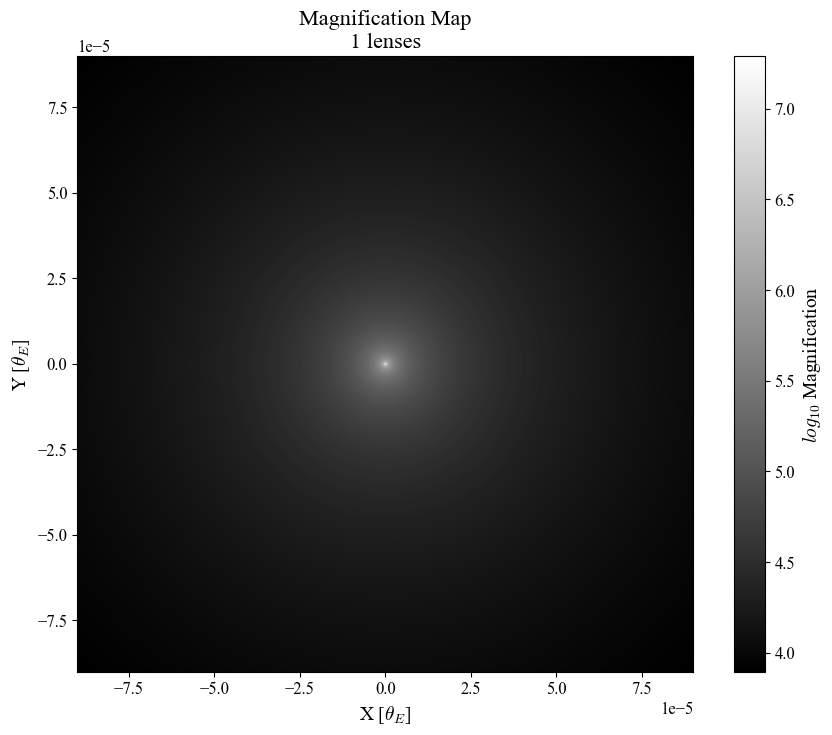

In [34]:
print(single_sim.param_dict)
single_sim.plot()

plt.show()

#### Plotting binary lens magnification map

{'pixels': 2000, 'ang_width': np.float64(0.000180001799946), 'thickness': np.float64(0.0001400085427043), 'y_plus': np.float64(1.000070006721651), 'y_minus': np.float64(-0.9999299981789468), 'lens_att': [[-1.1999640010799677e-05, 0.0, 1.0], [0.4999880003599892, 0.0, 3e-05]], 'num_theta': 203538, 'num_r': 814152, 'ang_res': np.float64(9.004592293446724e-08), 'pixel_density': np.float64(11105444.504442144), 'dr': np.float64(1.7196876587303827e-10), 'dtheta': 0.0017687114936768564, 'num_rays': 165710869776}
Plotting magnification map: 0.018 seconds


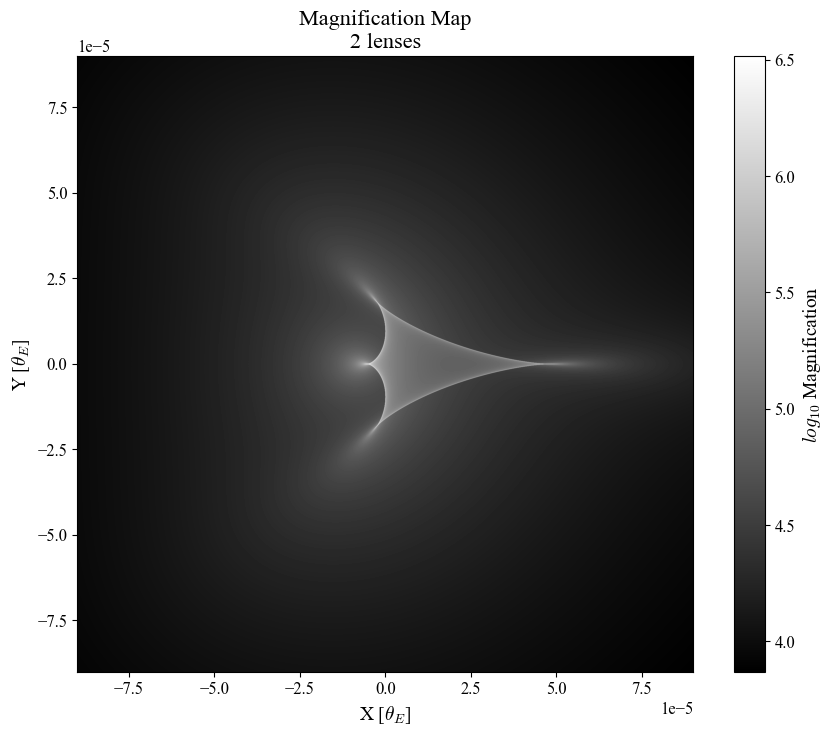

In [35]:
print(binary_sim.param_dict)
binary_sim.plot()

plt.show()

#### Defining source profile

In [36]:
radius = 1e-2
LD = 0.5

source_profile_size = int(2 * radius / ang_res)
print(source_profile_size)

222220


In [26]:
source_profile = IRSF.IRSFunctions.source_profile(ang_res=ang_res, rad=radius, profile_type='LD', LD=LD, supersample=10)

if source_profile_size < 10000:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot()

    img = ax.imshow(source_profile, cmap='afmhot', extent=[-radius - ang_res / 2, radius + ang_res / 2, -radius - ang_res / 2, radius + ang_res / 2])
    plt.colorbar(img, ax=ax, label='Source Brightness')

    source_patch = patches.Circle((0, 0), radius, color='blue', alpha=1, label='Source', zorder=10, fill=False, linewidth=2)
    ax.add_patch(source_patch)

    ax.set_xlabel('X [$\\theta_E$]')
    ax.set_ylabel('Y [$\\theta_E$]')
    ax.set_title('Source Profile')

    ax.set_aspect('equal')

    plt.show()

else:
    print('Source profile is too large to display.')

 14%|█▎        | 1538/11223 [00:19<02:02, 78.92it/s]


KeyboardInterrupt: 

#### Convolving single lens and binary lens magnification maps with source profile

In [9]:
single_brightnesses = single_sim.convolve(source_profile)
binary_brightnesses = binary_sim.convolve(source_profile)

Convolving source profile with magnification map: 0.156 seconds
Convolving source profile with magnification map: 0.134 seconds


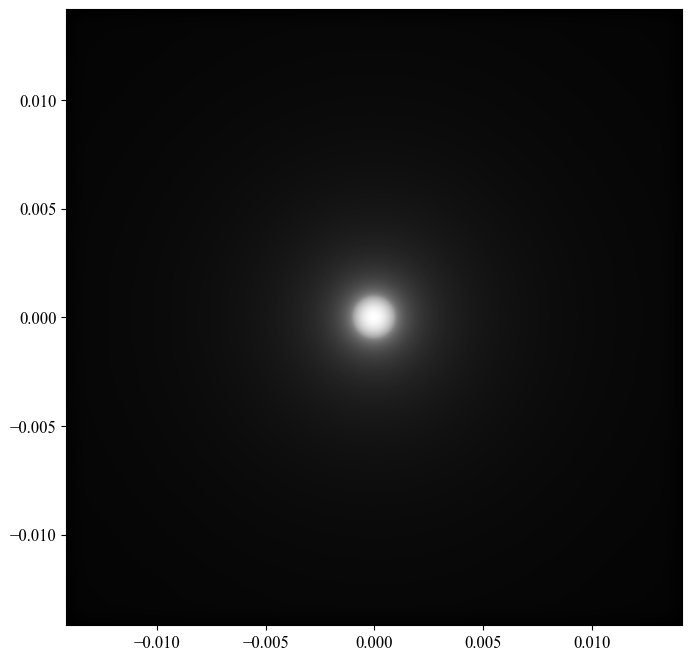

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.imshow(single_brightnesses, cmap='gray', extent=[-ang_width/2 - ang_res/2, ang_width / 2 + ang_res/2, -ang_width / 2 - ang_res/2, ang_width / 2 + ang_res/2])

plt.show()

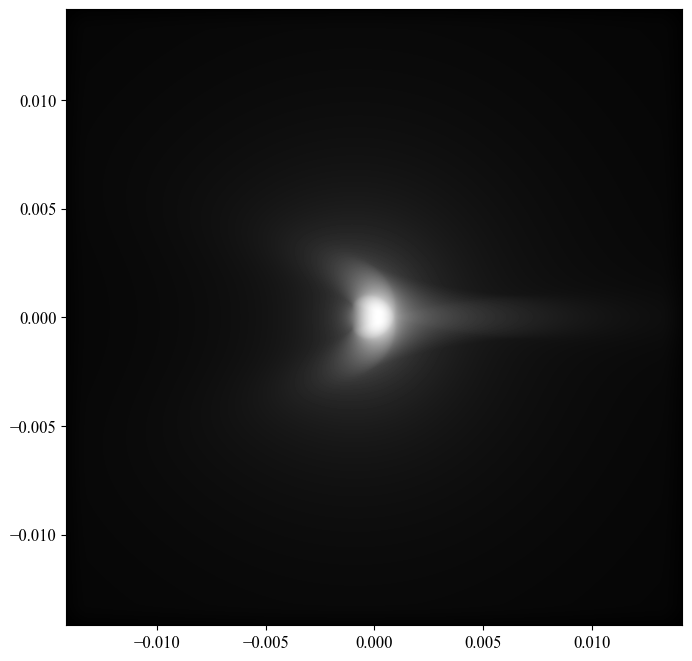

In [11]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.imshow(binary_brightnesses, cmap='gray', extent=[-ang_width/2 - ang_res/2, ang_width / 2 + ang_res/2, -ang_width / 2 - ang_res/2, ang_width / 2 + ang_res/2])

plt.show()

#### Computing fractional deviation between binary and single lens convolved brightnesses

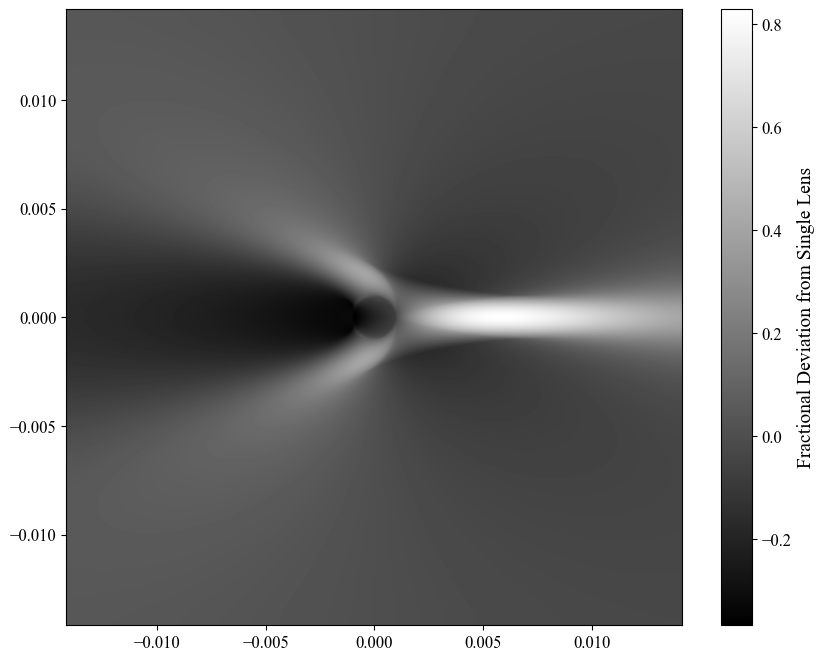

In [12]:
fractional_deviation = (binary_brightnesses - single_brightnesses) / single_brightnesses

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

img = ax.imshow(fractional_deviation, cmap='gray', extent=[-ang_width/2 - ang_res/2, ang_width / 2 + ang_res/2, -ang_width / 2 - ang_res/2, ang_width / 2 + ang_res/2])
plt.colorbar(img, ax=ax, label='Fractional Deviation from Single Lens')

plt.show()

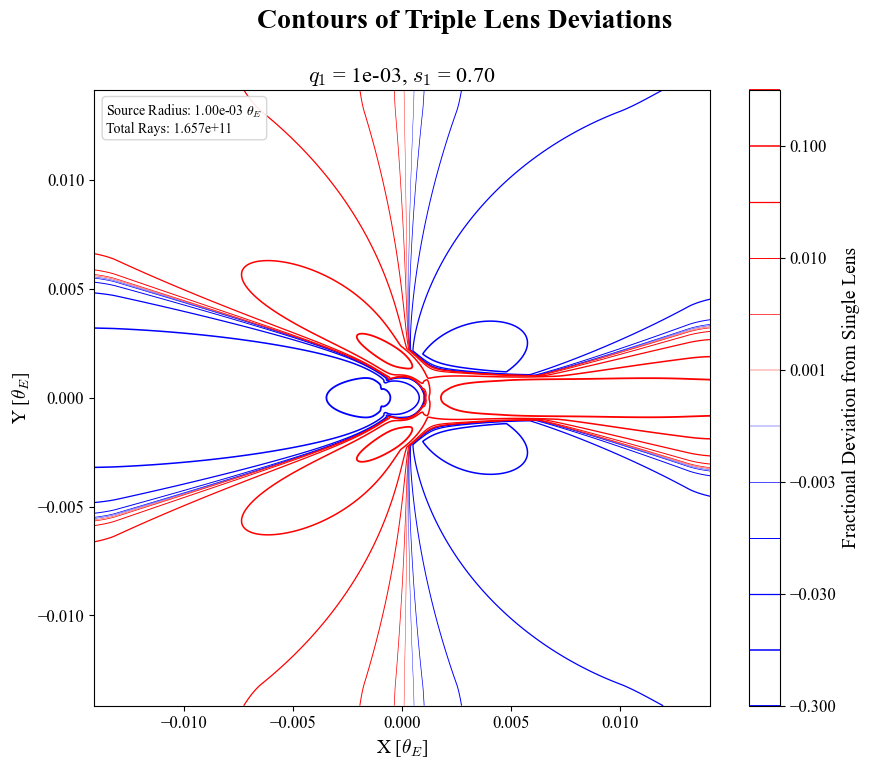

In [13]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Contours of Triple Lens Deviations')

img = plt.contour(single_sim.X_pix, single_sim.Y_pix, fractional_deviation,
                  levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                  colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                  linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                  zorder=0
)

bar = plt.colorbar(img)
bar.set_label('Fractional Deviation from Single Lens')

ax.set_title(f'$q_1$ = {q1s[q1_ind]:.0e}, $s_1$ = {s1s[s1_ind]:.2f}')
ax.set_aspect('equal')
ax.set_xlim(-ang_width/2, ang_width/2)
ax.set_ylim(-ang_width/2, ang_width/2)

props = dict(boxstyle='round', facecolor='white', edgecolor='lightgray', alpha=0.9)
ax.text(0.02, 0.98, f'Source Radius: {radius:.2e} $\\theta_E$\nTotal Rays: {(single_sim.num_rays):.3e}', va='top', zorder=10, bbox=props, transform=ax.transAxes, color='black')

ax.set_xlabel('X [$\\theta_E$]')
ax.set_ylabel('Y [$\\theta_E$]')

# fig.savefig('Contours_Accurate.png', dpi=500)

plt.show()

#### Finding ratio of area

In [14]:
x = np.logspace(-7, 0, 8)

for threshold in x:
    print(f'Threshold: {threshold}')
    area = np.sum(np.abs(fractional_deviation) < threshold) / pixels**2
    print(area)

Threshold: 1e-07
2.5e-07
Threshold: 1e-06
6e-06
Threshold: 1e-05
6.9e-05
Threshold: 0.0001
0.000719
Threshold: 0.001
0.00700975
Threshold: 0.01
0.0710655
Threshold: 0.1
0.8073035
Threshold: 1.0
1.0


#### Repeating for every binary lens configuration